# TASK 3: ENERGY CONSUMPTION FORECASTING


# Problem Statement


In [1]:
print("Energy Consumption Forecasting")

print("Forecast household energy usage")

Energy Consumption Forecasting
Forecast household energy usage


# Import Libraries

In [2]:
import pandas as pd

import matplotlib.pyplot as plt

# Import Machine Learning Libraries


In [3]:
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error

# Upload Dataset From UCI

In [4]:
from google.colab import files

uploaded = files.upload()

Saving individual+household+electric+power+consumption.zip to individual+household+electric+power+consumption.zip


In [6]:
import os

os.listdir()

['.config',
 'individual+household+electric+power+consumption.zip',
 'sample_data']

In [8]:
import zipfile

with zipfile.ZipFile("individual+household+electric+power+consumption.zip", "r") as zip_ref:
    zip_ref.extractall("data")

In [9]:
os.listdir("data")

['household_power_consumption.txt']

In [10]:
import pandas as pd

df = pd.read_csv("data/household_power_consumption.txt", sep=";")
df.head()

/tmp/ipykernel_24575/2082049984.py:3: DtypeWarning: Columns (2,3,4,5,6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data/household_power_consumption.txt", sep=";")


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


# Load Dataset

In [12]:
df = pd.read_csv(
    "data/household_power_consumption.txt",
    sep=";",
    low_memory=False
)

# Display Dataset

In [13]:
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


# Dataset Information

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    object 
 3   Global_reactive_power  object 
 4   Voltage                object 
 5   Global_intensity       object 
 6   Sub_metering_1         object 
 7   Sub_metering_2         object 
 8   Sub_metering_3         float64
dtypes: float64(1), object(8)
memory usage: 142.5+ MB


# Convert Date Column

In [15]:
df['Date'] = pd.to_datetime(df['Date'])

/tmp/ipykernel_24575/2394721818.py:1: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])


# Extract Month and Day


In [16]:
df['Month'] = df['Date'].dt.month

df['Day'] = df['Date'].dt.day

# Features and Target


In [18]:
# Features
X = df[['Month', 'Day']]

# Target (correct column)
y = df['Global_active_power']

# Train Test Split

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Model Building

In [20]:
model = LinearRegression()

In [23]:
import numpy as np

df = df.replace('?', np.nan)

In [24]:
cols = [
    "Global_active_power",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3"
]

for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [25]:
df = df.dropna()

In [26]:
df.isnull().sum()

,0
Date,0
Time,0
Global_active_power,0
Global_reactive_power,0
Voltage,0
Global_intensity,0
Sub_metering_1,0
Sub_metering_2,0
Sub_metering_3,0
Month,0


In [28]:
import numpy as np
import pandas as pd

df = pd.read_csv(
    "data/household_power_consumption.txt",
    sep=";",
    low_memory=False
)

In [29]:
df = df.replace("?", np.nan)

In [30]:
cols = [
    "Global_active_power",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3"
]

for col in cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [31]:
df = df.dropna()

In [32]:
X = df[['Global_reactive_power', 'Voltage', 'Global_intensity']]
y = df['Global_active_power']

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Model

In [34]:
model.fit(X_train, y_train)

LinearRegression()

# Prediction

In [35]:
y_pred = model.predict(X_test)

# Evaluation

In [36]:
mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

MAE: 0.028665778831607935


# Visualization

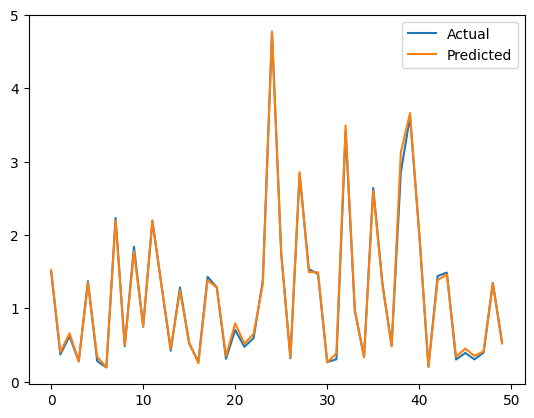

In [37]:
plt.plot(y_test.values[:50], label='Actual')

plt.plot(y_pred[:50], label='Predicted')

plt.legend()

plt.show()

# Conclusion


In [38]:
print("Energy forecasting completed successfully")

Energy forecasting completed successfully
